In [ ]:
!pip install ultralytics

In [ ]:
!pip install pafy youtube-dl

In [ ]:
from yt_dlp import YoutubeDL
from ultralytics import YOLO
import subprocess
import numpy as np
import cv2
from IPython.display import display, clear_output,Image
import PIL.Image
import time

In [ ]:
#Parameters
YOUTUBE_URL = "https://www.youtube.com/live/rnXIjl_Rzy4?feature=shared"  #  URL
TARGET_FPS  = 30
MODEL_PATH  = "best.pt"

#RESOLVE RAW STREAM URL
ydl_opts = {'format':'best[ext=mp4]', 'quiet':True}
with YoutubeDL(ydl_opts) as ydl:
    info       = ydl.extract_info(YOUTUBE_URL, download=False)
    stream_url = info['url']
    width      = info.get('width', 640)
    height     = info.get('height', 360)

print(f"Stream URL:   {stream_url}")
print(f"Resolution:   {width}×{height}")

# Load the model
model = YOLO(MODEL_PATH)
model.fuse()


Stream URL:   https://manifest.googlevideo.com/api/manifest/hls_playlist/expire/1745820772/ei/BMgOaI_9B4SpkucPi8nHsA0/ip/34.125.156.61/id/rnXIjl_Rzy4.1/itag/96/source/yt_live_broadcast/requiressl/yes/ratebypass/yes/live/1/sgoap/gir%3Dyes%3Bitag%3D140/sgovp/gir%3Dyes%3Bitag%3D137/rqh/1/hls_chunk_host/rr5---sn-q4fl6nzy.googlevideo.com/xpc/EgVo2aDSNQ%3D%3D/playlist_duration/30/manifest_duration/30/bui/AecWEAZD4-O-z_BbwFSWTCg6Vhxh3-m09S_aCnZwVFUtOH2s59BtdsNsOZ_D1ys5isBnMemG_usxj0dd/spc/wk1kZuqRHCQbMzEG7vVpMR0B6c4_r9yFXNanL8mF0gVf5ShsKzHATkEtIDL-rC6_EYy8KiU/vprv/1/playlist_type/DVR/met/1745799173,/mh/K2/mm/44/mn/sn-q4fl6nzy/ms/lva/mv/m/mvi/5/pl/20/rms/lva,lva/dover/11/pacing/0/keepalive/yes/fexp/51355912/mt/1745798909/sparams/expire,ei,ip,id,itag,source,requiressl,ratebypass,live,sgoap,sgovp,rqh,xpc,playlist_duration,manifest_duration,bui,spc,vprv,playlist_type/sig/AJfQdSswRQIgWYIOz1JXcA3ZHxDCKww7CxKpsCcXH_y4U8yUH7sZajoCIQDE8x0_dj4h6iwuWy2tCxmIk7-A3n-Tsd6chnE0qpxKtw%3D%3D/lsparams/hls_chunk

In [ ]:
import torch
print(torch.cuda.is_available())


True


In [ ]:
# Resolve stream URL, metadata & source FPS
with YoutubeDL({'format':'best[ext=mp4]','quiet':True}) as ydl:
    info       = ydl.extract_info(YOUTUBE_URL, download=False)
    stream_url = info['url']
    width      = info.get('width', 640)
    height     = info.get('height', 360)

# use ffprobe to get the feed's r_frame_rate
fps_cmd = [
    'ffprobe', '-v', '0',
    '-of', 'csv=p=0',
    '-select_streams', 'v:0',
    '-show_entries', 'stream=r_frame_rate',
    stream_url
]
rate = subprocess.check_output(fps_cmd).decode().strip()
# Split the rate string by newlines and take the first valid entry
for line in rate.split('\n'):
    if '/' in line:  # Check if the line contains a '/' for a valid frame rate
        try:
            num, den = map(int, line.split('/'))
            fps = num / den
            break  # Exit the loop once a valid frame rate is found
        except ValueError:
            pass  # Ignore lines that cannot be parsed
else:
    # Handle the case where no valid frame rate is found
    fps = 25  d

frame_interval = 1.0 / fps
print(f"Detected source FPS: {fps:.2f}")

Detected source FPS: 30.00


In [ ]:
# START FFMPEG PIPE
ffmpeg_cmd = [
    'ffmpeg', '-i', stream_url,
    '-loglevel', 'quiet', '-an',
    '-f', 'rawvideo', '-pix_fmt', 'bgr24', '-'
]
pipe = subprocess.Popen(ffmpeg_cmd, stdout=subprocess.PIPE, bufsize=10**8)

frame_bytes    = width * height * 3
frame_interval = 0.5 / TARGET_FPS

try:
    while True:
        start = time.time()

        # Read one raw frame
        raw = pipe.stdout.read(frame_bytes)
        if len(raw) < frame_bytes:
            print("Stream ended.")
            break
        frame = np.frombuffer(raw, np.uint8).reshape((height, width, 3))

        # Run detection
        results   = model(frame, conf=0.25, iou=0.45, device='cpu')
        annotated = results[0].plot()

        # Display in-place as a continuous video
        img = PIL.Image.fromarray(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        clear_output(wait=True)
        display(img)

        # Sleep to maintain TARGET_FPS
        elapsed = time.time() - start
        if elapsed < frame_interval:
            time.sleep(frame_interval - elapsed)

finally:
    pipe.terminate()
    cv2.destroyAllWindows()


_____________TESTING______________


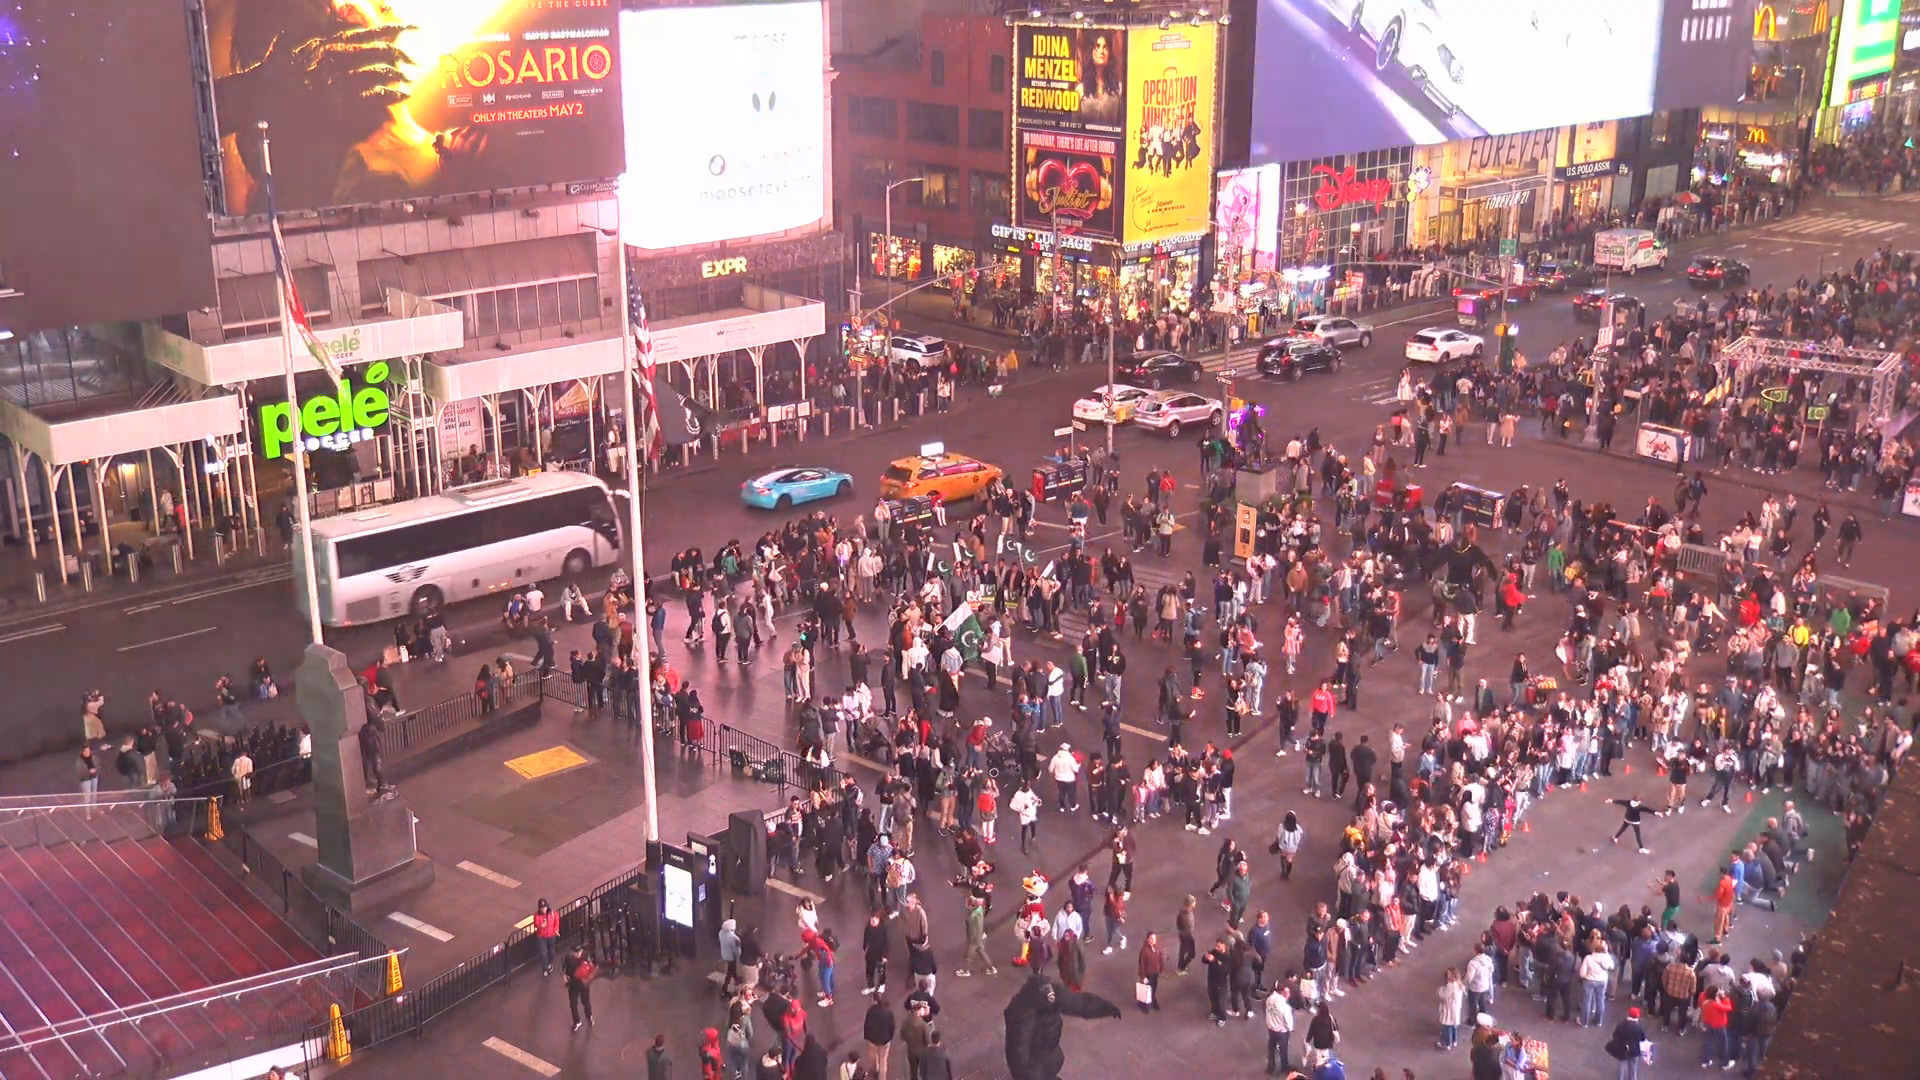

KeyboardInterrupt: 

In [ ]:
#START FFMPEG PIPE
ffmpeg_cmd = [
    'ffmpeg', '-i', stream_url,
    '-loglevel', 'quiet', '-an',
    '-f', 'rawvideo', '-pix_fmt', 'bgr24', '-'
]
pipe = subprocess.Popen(ffmpeg_cmd, stdout=subprocess.PIPE, bufsize=10**8)

frame_bytes    = width * height * 3
frame_interval = 1.0 / TARGET_FPS

try:
    while True:
        start = time.time()

        # a) Read one raw frame
        raw = pipe.stdout.read(frame_bytes)
        if len(raw) < frame_bytes:
            print("Stream ended.")
            break
        frame = np.frombuffer(raw, np.uint8).reshape((height, width, 3))

        # b) Run detection
        results   = model(frame, conf=0.25, iou=0.45, device='cpu')
        annotated = results[0].plot()

        # c) Display in-place as a continuous video
        img = PIL.Image.fromarray(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        clear_output(wait=True)
        display(img)

        # d) Sleep to maintain TARGET_FPS
        elapsed = time.time() - start
        if elapsed < frame_interval:
            time.sleep(frame_interval - elapsed)

finally:
    pipe.terminate()
    cv2.destroyAllWindows()
